Samuel Shrestha

In [3]:
#importing necessary packages
import requests
from bs4 import BeautifulSoup
import pandas as pd

#urls used 
url_3p_pct = "https://www.teamrankings.com/nba/stat/three-point-pct"
url_3pa = "https://www.teamrankings.com/nba/stat/three-pointers-attempted-per-game"
url_offensive_efficiency = "https://www.teamrankings.com/nba/stat/offensive-efficiency"

#scraping the team names and stats
def scrape_stats(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.content, 'html.parser')
    
    #getting table rows
    table = soup.find('table', {'class': 'tr-table'}).find('tbody').find_all('tr')
    
    #lists for team and stats
    teams = []
    stats = []
    
    #getting the team names and stats
    for row in table:
        columns = row.find_all('td')
        team = columns[1].text.strip()
        stat = columns[2].text.strip()
        
        #cleaning the data by removing the '%' symbol and convert the value to a float
        stat = stat.replace('%', '').strip()
        teams.append(team)
        stats.append(float(stat))
    
    return teams, stats

#scraping for 3pt %, 3pa, and offensive efficiency
teams_3p_pct, stats_3p_pct = scrape_stats(url_3p_pct)
teams_3pa, stats_3pa = scrape_stats(url_3pa)
teams_efficiency, stats_efficiency = scrape_stats(url_offensive_efficiency)

#making dfs for each dataset
df_3p_pct = pd.DataFrame({'Team': teams_3p_pct, '3P%': stats_3p_pct})
df_3pa = pd.DataFrame({'Team': teams_3pa, '3PA': stats_3pa})
df_efficiency = pd.DataFrame({'Team': teams_efficiency, 'ORtg': stats_efficiency})

#merging them all together
df_merged = pd.merge(pd.merge(df_3p_pct, df_3pa, on='Team'), df_efficiency, on='Team')

#sorting in alphabetical order
df_merged = df_merged.sort_values(by='Team').reset_index(drop=True)

#converting to csv file
df_merged.to_csv('nba_shooting_and_offense.csv', index=False)

print(df_merged)

            Team   3P%   3PA   ORtg
0        Atlanta  32.1  28.0  1.113
1         Boston  43.4  53.0  1.277
2       Brooklyn  39.5  43.0  1.075
3      Charlotte  38.5  39.0  1.084
4        Chicago  29.4  34.0  1.001
5      Cleveland  46.7  30.0  1.301
6         Dallas  43.2  44.0  1.141
7         Denver  18.4  38.0  0.831
8        Detroit  27.3  33.0  1.057
9   Golden State  41.7  48.0  1.264
10       Houston  30.2  43.0  1.035
11       Indiana  29.0  31.0  1.116
12   LA Clippers  27.6  29.0  0.994
13     LA Lakers  16.7  30.0  1.096
14       Memphis  37.8  45.0  1.169
15         Miami  32.4  34.0  0.969
16     Milwaukee  43.2  37.0  1.212
17     Minnesota  36.3  45.5  1.075
18   New Orleans  37.8  37.0  1.109
19      New York  36.7  30.0  1.182
20     Okla City  22.2  36.0  0.974
21       Orlando  36.7  49.0  1.159
22  Philadelphia  25.8  31.0  1.066
23       Phoenix  39.5  38.0  1.020
24      Portland  23.5  34.0  0.939
25    Sacramento  37.9  29.0  1.102
26   San Antonio  33.3  36.0

In [4]:
# Covariance matrix
import matplotlib.pyplot as plt

cov_matrix = df_merged.select_dtypes(include = ['float64', 'int64']).cov()

cov_matrix

,3P%,3PA,ORtg
3P%,64.887402,18.618391,0.622794
3PA,18.618391,48.622126,0.184940
ORtg,0.622794,0.184940,0.011131


In [5]:
variance = df_merged.select_dtypes(include = ['float64', 'int64']).var()
variance

3P%     64.887402
3PA     48.622126
ORtg     0.011131
dtype: float64

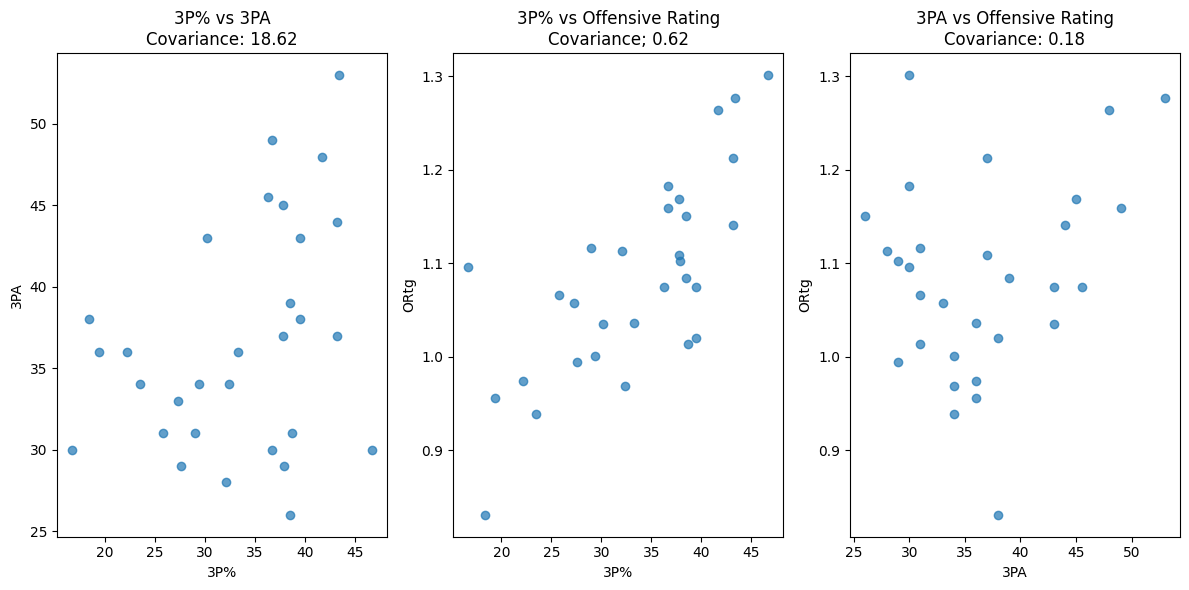

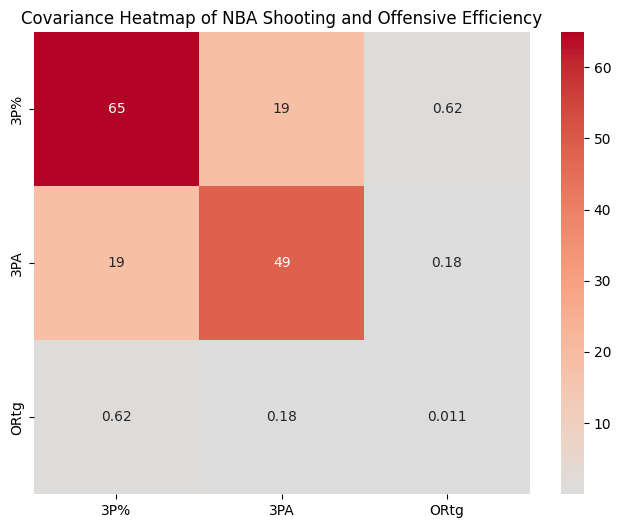

In [6]:
# Scatterplots and heat map of the covariance
import seaborn as sns

df = pd.read_csv('nba_shooting_and_offense.csv')

plt.figure(figsize = (12,6))

# 3P% vs 3PA
plt.subplot(1, 3, 1)
plt.scatter(df['3P%'], df['3PA'], alpha = 0.7)
cov_3p3pa = df['3P%'].cov(df['3PA'])
plt.title(f'3P% vs 3PA\nCovariance: {cov_3p3pa:.2f}')
plt.xlabel('3P%')
plt.ylabel('3PA')

# 3P% vs Offensive Rating
plt.subplot(1, 3, 2)
plt.scatter(df['3P%'], df['ORtg'], alpha = 0.7)
cov_3pOrtg = df['3P%'].cov(df['ORtg'])
plt.title(f'3P% vs Offensive Rating\nCovariance; {cov_3pOrtg:.2f}')
plt.xlabel('3P%')
plt.ylabel('ORtg')

# 3PA vs Offesive Rating
plt.subplot(1, 3, 3)
plt.scatter(df['3PA'], df['ORtg'], alpha = 0.7)
cov_3paORtg = df['3PA'].cov(df['ORtg'])
plt.title(f'3PA vs Offensive Rating\nCovariance: {cov_3paORtg:.2f}')
plt.xlabel('3PA')
plt.ylabel('ORtg')

plt.tight_layout()
plt.show()


# Covariance Heat Map
plt.figure(figsize = (8, 6))
sns.heatmap(df[['3P%', '3PA', 'ORtg']].cov(), annot = True, cmap = 'coolwarm', center = 0)
plt.title('Covariance Heatmap of NBA Shooting and Offensive Efficiency')
plt.show()

## What can we infer from the Covarience

### 3P% and 3PA (Covariance: 19)
The heatmap shows a significant positive covariance between three-point percentage and three-point attempts, which aligns with the scatterplot. This shows that teams that shoot more tend to also shoot at higher percentages.
### 3P% and ORtg (Covariance: 0.62):
There is a weak positive covariance between three-point shooting percentage and offensive efficiency, as reflected in the scatterplot. This suggests that while accuracy from three-pointers contributes to offensive efficiency, it is not the sole driver (since there are other ways to get pts as well).
### 3PA and ORtg (Covariance: 0.18):
The covariance between three-point attempts and offensive efficiency is quite low, indicating that the volume of three-point attempts alone does not significantly contribute to overall offensive efficiency. This suggests that the quality of three-point shots (e.g., shot selection, player skill) may be more important than the quantity in contributing to efficient offense.